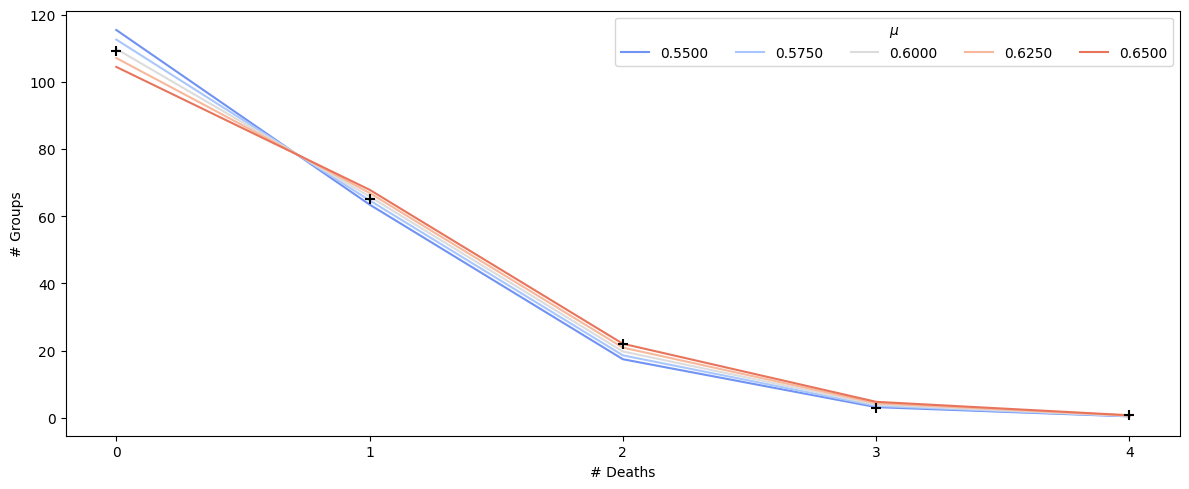

In [23]:
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
from scipy import stats

nDeaths = np.array([0, 1, 2, 3, 4])
nGroups = np.array([109, 65, 22, 3, 1])

fig, axs = plt.subplots(figsize=(12, 5), tight_layout=True)
axs.scatter(nDeaths, nGroups, marker='+', s=50, c='k', zorder=1)
poisson = lambda x, mu: stats.poisson(mu).pmf(x)*np.sum(nGroups)

dMu = 0.025
muArray = np.arange(0.55, 0.65+dMu, dMu)
import seaborn as sns
lColors = sns.color_palette('coolwarm', as_cmap=False, n_colors=len(muArray))

for c, mu in enumerate(muArray):
    score = np.sum( poisson(nDeaths, mu)[0] - nGroups[0] )
    plt.plot(nDeaths, poisson(nDeaths, mu), zorder=-1, lw=1.5, ls='-', label='{0:=.4f}'.format(mu), c=lColors[c])

axs.legend(title=r'$\mu$', loc='upper right', ncol=5)
axs.set_xlabel('# Deaths')
axs.set_ylabel('# Groups')
_ = axs.set_xticks([0,1,2,3,4])